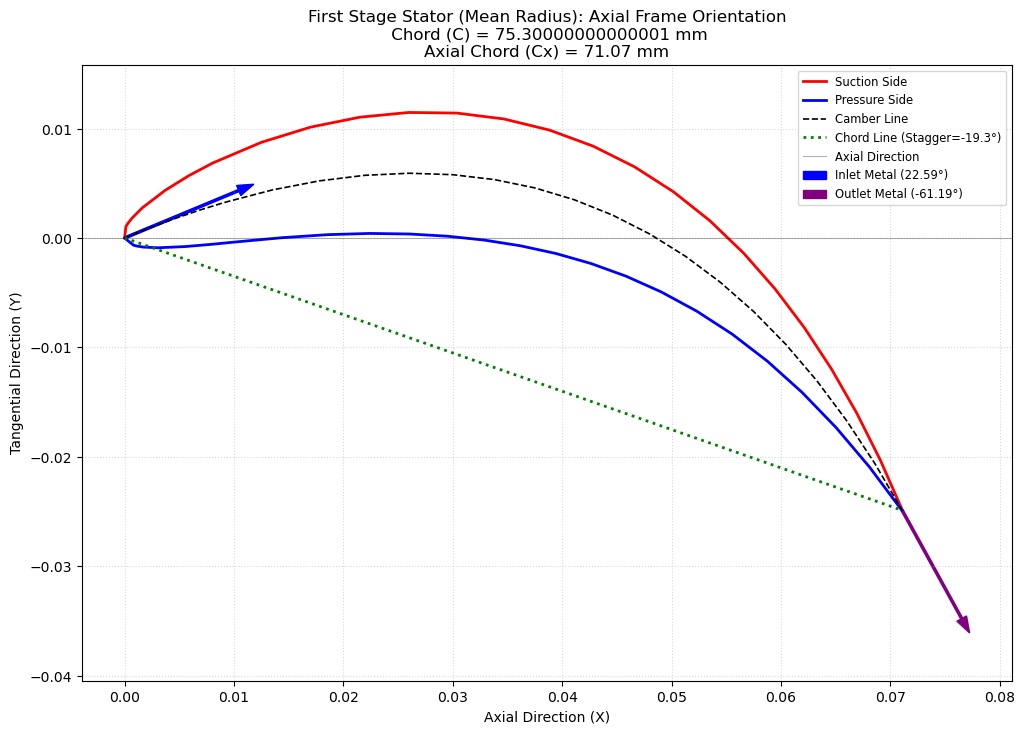

In [ ]:
# BLADE GEOMETRY MODULE

import numpy as np
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. INPUT PARAMETERS
# ========================================== 
# section
stator_or_rotor = ["Stator" ,"Stator" ,"Stator" , "Rotor", "Rotor", "Rotor"]
radial_section = ["Hub", "Mean", "Tip", "Hub", "Mean", "Tip"]
chord_length = [0.0426, 0.0593, 0.0762, 0.0753, 0.0753, 0.0753]  # Meters # change
t_max_target = 0.15    # 15% thickness

# The code is basically mapping the NACA profile (zero camber) to a parobolic camber that is defined with inlet and outlet metal angles


# Angles for Mean station
chi_in = [0, 0, 0, 22.59, 0, -15.93]      # change
chi_out = [65.89, 61.19, 56.88, -61.19, -61.19, -61.19] # change
gamma = [32.94, 30.59, 28.44, -19.30, -30.59, -38.56] # change



# NACA 63012A Data (Normalised 0-1)
naca_data = np.array([
    [0.0000, 0.00000], [0.0050, 0.00973], [0.0075, 0.01173], [0.0125, 0.01492],
    [0.0250, 0.02078], [0.0500, 0.02895], [0.0750, 0.03504], [0.1000, 0.03994],
    [0.1500, 0.04747], [0.2000, 0.05287], [0.2500, 0.05664], [0.3000, 0.05901],
    [0.3500, 0.05995], [0.4000, 0.05957], [0.4500, 0.05792], [0.5000, 0.05517],
    [0.5500, 0.05148], [0.6000, 0.04700], [0.6500, 0.04186], [0.7000, 0.03621],
    [0.7500, 0.03026], [0.8000, 0.02426], [0.8500, 0.01826], [0.9000, 0.01225],
    [0.9500, 0.00625], [1.0000, 0.00025]
])

# ==========================================
# 2. GEOMETRY GENERATION LOGIC
# ==========================================

def rotate_coords(x, y, angle_deg):
    """Rotates coordinates around the origin (0,0)."""
    rad = math.radians(angle_deg)
    xr = x * math.cos(rad) - y * math.sin(rad)
    yr = x * math.sin(rad) + y * math.cos(rad)
    return xr, yr

def generate_blade_geometry(chord, naca_coords, c_in, c_out, g, thickness_ratio):
    x_naca = naca_coords[:, 0]
    yt = naca_coords[:, 1] * (thickness_ratio / 0.12)
    
    chi_in_rel = math.radians(c_in - g)
    B = math.tan(chi_in_rel)
    A = -B 
    
    xu, yu, xl, yl, xc_line, yc_line = [], [], [], [], [], []
    
    for i in range(len(x_naca)):
        x = x_naca[i]
        yc = (A * x**2 + B * x) * chord
        xc = x * chord
        theta = math.atan(2 * A * x + B)
        
        # Local offsets
        xu.append(xc - (yt[i] * chord * math.sin(theta)))
        yu.append(yc + (yt[i] * chord * math.cos(theta)))
        xl.append(xc + (yt[i] * chord * math.sin(theta)))
        yl.append(yc - (yt[i] * chord * math.cos(theta)))
        xc_line.append(xc)
        yc_line.append(yc)
        
    # Rotate all to Global Axial Frame
    xu_r, yu_r = rotate_coords(np.array(xu), np.array(yu), g)
    xl_r, yl_r = rotate_coords(np.array(xl), np.array(yl), g)
    xc_r, yc_r = rotate_coords(np.array(xc_line), np.array(yc_line), g)
        
    return xu_r, yu_r, xl_r, yl_r, xc_r, yc_r


# ==========================================
# 3. OUTPUT & PLOTTING (Axial Orientation)
# ==========================================

xu, yu, xl, yl, xc, yc = generate_blade_geometry(chord_length, naca_data, chi_in, chi_out, gamma, t_max_target)

plt.figure(figsize=(12, 8))

# 1. Profile and Camber
plt.plot(xu, yu, 'r-', linewidth=2, label='Suction Side')
plt.plot(xl, yl, 'b-', linewidth=2, label='Pressure Side')
plt.plot(xc, yc, 'k--', linewidth=1.2, label='Camber Line')

# 2. Chord Line (Staggered relative to Axial)
c_line_x, c_line_y = rotate_coords(np.array([0, chord_length]), np.array([0, 0]), gamma)
plt.plot(c_line_x, c_line_y, 'g:', linewidth=2, label=f'Chord Line (Stagger={gamma:.1f}°)')

# 3. Axial Reference Line
plt.axhline(0, color='black', linewidth=0.8, alpha=0.3, label='Axial Direction')

# 4. Metal Angle Indicators
vec_len = chord_length * 0.15

# Inlet Vector
plt.arrow(xc[0], yc[0], math.cos(math.radians(chi_in))*vec_len, math.sin(math.radians(chi_in))*vec_len, 
          color='blue', width = 0.0002, head_width=0.001, label=f'Inlet Metal ({chi_in}°)')
# Outlet Vector (pointing away from TE)
plt.arrow(xc[-1], yc[-1], math.cos(math.radians(chi_out))*vec_len, math.sin(math.radians(chi_out))*vec_len, 
          color='purple', width = 0.0002, head_width=0.001, label=f'Outlet Metal ({chi_out}°)')

# Formatting
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.5)
plt.title(f"First Stage {stator_or_rotor} ({radial_section} Radius): Axial Frame Orientation\n Chord (C) = {chord_length * 1000} mm\nAxial Chord (Cx) = {chord_length * math.cos(math.radians(gamma)) * 1000:.2f} mm")
plt.xlabel("Axial Direction (X)")
plt.ylabel("Tangential Direction (Y)")
plt.legend(loc='best', fontsize='small')

plt.show()
plt.savefig("../images/{stator_or_rotor}_{radial_section}.png")

# EXPORT TO CSV
# Create a continuous loop: Suction side, then Pressure side reversed

x_coords = np.concatenate([xu, xl[::-1]])
y_coords = np.concatenate([yu, yl[::-1]])

# Stack into two columns: X and Y
geometry_data = np.column_stack((x_coords, y_coords))

# Specify directory and file name
dir = "../blade_geometry/"
file_name = f"{stator_or_rotor}_{radial_section}.csv"

# Save to CSV
header = "X_Coordinate,Y_Coordinate"
np.savetxt(dir + file_name, geometry_data, delimiter=",", header=header, comments='')


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. INPUT PARAMETERS
# ========================================== 
stator_or_rotor = ["Stator", "Stator", "Stator", "Rotor", "Rotor", "Rotor"]
radial_section = ["Hub", "Mean", "Tip", "Hub", "Mean", "Tip"]
chord_length = [0.0426, 0.0593, 0.0762, 0.0753, 0.0753, 0.0753] 
t_max_target = 0.15    

chi_in = [0, 0, 0, 22.59, 0, -15.93]      
chi_out = [65.89, 61.19, 56.88, -61.19, -61.19, -61.19] 
gamma = [32.94, 30.59, 28.44, -19.30, -30.59, -38.56] 

naca_data = np.array([
    [0.0000, 0.00000], [0.0050, 0.00973], [0.0075, 0.01173], [0.0125, 0.01492],
    [0.0250, 0.02078], [0.0500, 0.02895], [0.0750, 0.03504], [0.1000, 0.03994],
    [0.1500, 0.04747], [0.2000, 0.05287], [0.2500, 0.05664], [0.3000, 0.05901],
    [0.3500, 0.05995], [0.4000, 0.05957], [0.4500, 0.05792], [0.5000, 0.05517],
    [0.5500, 0.05148], [0.6000, 0.04700], [0.6500, 0.04186], [0.7000, 0.03621],
    [0.7500, 0.03026], [0.8000, 0.02426], [0.8500, 0.01826], [0.9000, 0.01225],
    [0.9500, 0.00625], [1.0000, 0.00025]
])

# Create directories if they don't exist
os.makedirs("../images", exist_ok=True)
os.makedirs("../blade_geometry", exist_ok=True)

# ==========================================
# 2. GEOMETRY GENERATION FUNCTIONS
# ==========================================

def rotate_coords(x, y, angle_deg):
    rad = math.radians(angle_deg)
    xr = x * math.cos(rad) - y * math.sin(rad)
    yr = x * math.sin(rad) + y * math.cos(rad)
    return xr, yr

def generate_blade_geometry(chord, naca_coords, c_in, c_out, g, thickness_ratio):
    x_naca = naca_coords[:, 0]
    yt = naca_coords[:, 1] * (thickness_ratio / 0.12)
    
    chi_in_rel = math.radians(c_in - g)
    B = math.tan(chi_in_rel)
    A = -B 
    
    xu, yu, xl, yl, xc_line, yc_line = [], [], [], [], [], []
    
    for i in range(len(x_naca)):
        x = x_naca[i]
        yc = (A * x**2 + B * x) * chord
        xc = x * chord
        theta = math.atan(2 * A * x + B)
        
        xu.append(xc - (yt[i] * chord * math.sin(theta)))
        yu.append(yc + (yt[i] * chord * math.cos(theta)))
        xl.append(xc + (yt[i] * chord * math.sin(theta)))
        yl.append(yc - (yt[i] * chord * math.cos(theta)))
        xc_line.append(xc)
        yc_line.append(yc)
        
    xu_r, yu_r = rotate_coords(np.array(xu), np.array(yu), g)
    xl_r, yl_r = rotate_coords(np.array(xl), np.array(yl), g)
    xc_r, yc_r = rotate_coords(np.array(xc_line), np.array(yc_line), g)
        
    return xu_r, yu_r, xl_r, yl_r, xc_r, yc_r

# ==========================================
# 3. MAIN LOOP THROUGH ALL SECTIONS
# ==========================================

for i in range(len(stator_or_rotor)):
    # Extract current parameters
    comp_type = stator_or_rotor[i]
    loc = radial_section[i]
    c = chord_length[i]
    cin = chi_in[i]
    cout = chi_out[i]
    g = gamma[i]
    
    # Generate Geometry
    xu, yu, xl, yl, xc, yc = generate_blade_geometry(c, naca_data, cin, cout, g, t_max_target)
    
    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    plt.plot(xu, yu, 'r-', linewidth=2, label='Suction Side')
    plt.plot(xl, yl, 'b-', linewidth=2, label='Pressure Side')
    plt.plot(xc, yc, 'k--', linewidth=1.2, label='Camber Line')

    # Chord Line
    c_line_x, c_line_y = rotate_coords(np.array([0, c]), np.array([0, 0]), g)
    plt.plot(c_line_x, c_line_y, 'g:', linewidth=2, label=f'Chord Line (Stagger={g:.1f}°)')

    # Metal Angle Indicators
    vec_len = c * 0.15
    plt.arrow(xc[0], yc[0], math.cos(math.radians(cin))*vec_len, math.sin(math.radians(cin))*vec_len, 
              color='blue', width=0.0002, head_width=0.001, label=f'Inlet ({cin}°)')
    plt.arrow(xc[-1], yc[-1], math.cos(math.radians(cout))*vec_len, math.sin(math.radians(cout))*vec_len, 
              color='purple', width=0.0002, head_width=0.001, label=f'Outlet ({cout}°)')

    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.title(f"{comp_type} - {loc} Section\nChord: {c*1000:.1f}mm | Axial Chord: {c*math.cos(math.radians(g))*1000:.2f}mm")
    plt.xlabel("Axial Direction (X)")
    plt.ylabel("Tangential Direction (Y)")
    plt.legend(loc='best', fontsize='x-small')

    # Save Plot
    plt.savefig(f"../images/{comp_type}_{loc}.png")
    plt.close() # Close to free up memory
    
    # --- EXPORT TO CSV ---
    x_coords = np.concatenate([xu, xl[::-1]])
    y_coords = np.concatenate([yu, yl[::-1]])
    geometry_data = np.column_stack((x_coords, y_coords))

    file_name = f"../blade_geometry/{comp_type}_{loc}.csv"
    np.savetxt(file_name, geometry_data, delimiter=",", header="X_Coordinate,Y_Coordinate", comments='')

    print(f"Processed: {comp_type} {loc}")

print("\nAll 6 sections successfully generated.")

Processed: Stator Hub
Processed: Stator Mean
Processed: Stator Tip
Processed: Rotor Hub
Processed: Rotor Mean
Processed: Rotor Tip

All 6 sections successfully generated.
